In [ ]:
# matrix factorization 

In [1]:
import pandas as pd
from surprise import Dataset, Reader, SVD, accuracy

ratings=pd.read_csv("/Users/harshverma/Downloads/machine learning /movie recommendation system/ml-latest-small/ratings.csv")
ratings_sorted = ratings.sort_values('timestamp').reset_index(drop=True)
split_index = int(len(ratings_sorted) * 0.8)

train_df = ratings_sorted.iloc[:split_index]
test_df = ratings_sorted.iloc[split_index:]

reader = Reader(rating_scale=(0.5, 5.0))
train_data = Dataset.load_from_df(train_df[['userId', 'movieId', 'rating']], reader)
trainset = train_data.build_full_trainset()

testset = list(zip(test_df['userId'], test_df['movieId'], test_df['rating']))

print("Trainset ratings:", trainset.n_ratings)
print("Testset size:", len(testset))

Trainset ratings: 80668
Testset size: 20168


In [2]:
#using gridsearch CV to find the best parameters 
from surprise.model_selection import GridSearchCV

param_grid = {
    'n_factors': [20, 50, 100],
    'n_epochs': [20, 30],
    'lr_all': [0.002, 0.005, 0.01],
    'reg_all': [0.02, 0.1]
}

gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3)
gs.fit(train_data)   # note: train_data (built earlier from train_df), NOT the full dataset

print("Best RMSE score:", gs.best_score['rmse'])
print("Best params for RMSE:", gs.best_params['rmse'])

print("\nBest MAE score:", gs.best_score['mae'])
print("Best params for MAE:", gs.best_params['mae'])

Best RMSE score: 0.8678550185821479
Best params for RMSE: {'n_factors': 100, 'n_epochs': 30, 'lr_all': 0.01, 'reg_all': 0.1}

Best MAE score: 0.6677197140697627
Best params for MAE: {'n_factors': 100, 'n_epochs': 30, 'lr_all': 0.01, 'reg_all': 0.1}


In [3]:
algo_svd = SVD(n_factors=100, n_epochs=30, lr_all=0.01, reg_all=0.1, random_state=42)
algo_svd.fit(trainset)

predictions_svd = algo_svd.test(testset)

print("SVD (default params):")
accuracy.rmse(predictions_svd)
accuracy.mae(predictions_svd)

SVD (default params):
RMSE: 1.0052
MAE:  0.7772


np.float64(0.7771574331924118)

In [5]:
results = []

for k in [10, 20, 50, 100, 150]:
    algo = SVD(n_factors=k, n_epochs=30, random_state=42)
    algo.fit(trainset)
    preds = algo.test(testset)
    rmse = accuracy.rmse(preds, verbose=False)
    mae = accuracy.mae(preds, verbose=False)
    results.append({'n_factors': k, 'rmse': rmse, 'mae': mae})
    print(f"k={k}: RMSE={rmse:.4f}, MAE={mae:.4f}")

results_df = pd.DataFrame(results)
results_df

k=10: RMSE=1.0144, MAE=0.7810
k=20: RMSE=1.0135, MAE=0.7807
k=50: RMSE=1.0139, MAE=0.7816
k=100: RMSE=1.0128, MAE=0.7823
k=150: RMSE=1.0143, MAE=0.7831


,n_factors,rmse,mae
0,10,1.014360,0.781024
1,20,1.013537,0.780664
2,50,1.013906,0.781591
3,100,1.012794,0.782279
4,150,1.014340,0.783075


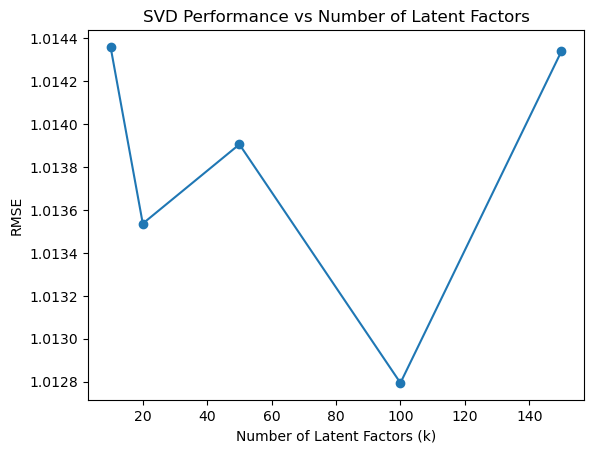

In [6]:
import matplotlib.pyplot as plt

plt.plot(results_df['n_factors'], results_df['rmse'], marker='o')
plt.xlabel('Number of Latent Factors (k)')
plt.ylabel('RMSE')
plt.title('SVD Performance vs Number of Latent Factors')
plt.show()